# Content and Objective

+ Show effects of quantization when filtering
+ Convolution is done in 1. time-domain and 2. in frequency domain using FFT

# Importing and Plotting Options

In [1]:
# importing
import numpy as np

import matplotlib.pyplot as plt
import matplotlib

# showing figures inline
%matplotlib inline

In [2]:
# plotting options 
font = {'size'   : 20}
plt.rc('font', **font)
plt.rc('text', usetex=True)

matplotlib.rc('figure', figsize=(18, 10) )

# Function Providing RRC Shape

In [3]:
########################
# find impulse response of an RRC filter
########################
def get_rrc_ir(K, n_up, t_symb, r):
        
    ''' 
    Determines coefficients of an RRC filter 
    
    Formula out of: J. Huber, Trelliscodierung, Springer, 1992, S. 15
    At poles, values of wikipedia.de were used (without cross-checking)
    
    NOTE: Length of the IR has to be an odd number
    
    IN: length of IR, upsampling factor, symbol time, roll-off factor
    OUT: filter ceofficients
    '''

    assert K % 2 != 0, "Filter length needs to be odd"
    
    if r == 0:
        r = 1e-32

    # init
    rrc = np.zeros(K)
    t_sample = t_symb/n_up
    
        
    i_steps = np.arange( 0, K)
    k_steps = np.arange( -(K-1)/2.0, (K-1)/2.0 + 1 )    
    t_steps = k_steps*t_sample

    for i in i_steps:

        if t_steps[i] == 0:
            rrc[i] = 1.0/np.sqrt(t_symb) * (1.0 - r + 4.0 * r / np.pi )

        elif np.abs( t_steps[i] ) == t_symb/4.0/r:
            rrc[i] = r/np.sqrt(2.0*t_symb)*((1+2/np.pi)*np.sin(np.pi/4.0/r)+ \
                            ( 1.0 - 2.0/np.pi ) * np.cos(np.pi/4.0/r) )

        else:
            rrc[i] = 1.0/np.sqrt(t_symb)*( np.sin( np.pi*t_steps[i]/t_symb*(1-r) ) + \
                            4.0*r*t_steps[i]/t_symb * np.cos( np.pi*t_steps[i]/t_symb*(1+r) ) ) \
                            / (np.pi*t_steps[i]/t_symb*(1.0-(4.0*r*t_steps[i]/t_symb)**2.0))
 
    return rrc

# Function for Quantization

In [4]:
def quant(x, b):  
    """ Quantizes a given input vector to 2^b levels.
    
    Levels are determined equidistantly in [-1, 1];
    lowest level is -1, highest 1-2^-b.
    
    IN: vector of samples; normalized to [-1, 1]
    
    OUT: quantized vetor
    """
   
    numb_levels = 2**b
    delta = 2.0 / numb_levels  
    
    # find quantization levels 
    levels = [ -1.0 + k * delta for k in np.arange( numb_levels ) ]
    
    x_q = []
    for xi in x:
        
        # find arg min of distance between xi and levels and choose according quant. level
        x_q.append( levels[ np.argmin( np.abs( xi - levels ) ) ] )

    return np.array( x_q )

# Simulating Effects

In [8]:
# parameters for rrc
t_symb = 1.0
beta = 0.33

# oversampling factor; samples per symbol
n_sps = 8        

# symbols per filter (plus minus in both directions)
syms_per_filt = 4  

# length of the fir filter
K_filt = 2 * syms_per_filt * n_sps + 1         

# get rrc impulse response
rrc = get_rrc_ir( K_filt, n_sps, t_symb, beta )
rrc /= np.linalg.norm( rrc )

In [29]:
# ideal convolution
rc_ideal = np.convolve( rrc, rrc )

# quantize rrc
N_bit = 4
rrc_max = np.max( np.abs( rrc ) )

rrc_quant = quant( rrc/rrc_max, N_bit ) * rrc_max

# convolution in time domain
rc_quant_time = np.convolve( rrc_quant, rrc_quant )

# convolution in frequency domain
RRC_quant = np.fft.fft( np.fft.fftshift( np.append( rrc_quant, np.zeros_like( rrc_quant ) ) ) )
RC_quant = RRC_quant * RRC_quant

rc_quant_freq = np.fft.ifft( RC_quant )

/home/jaekel/.anaconda3/lib/python3.7/site-packages/numpy/core/_asarray.py:85: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


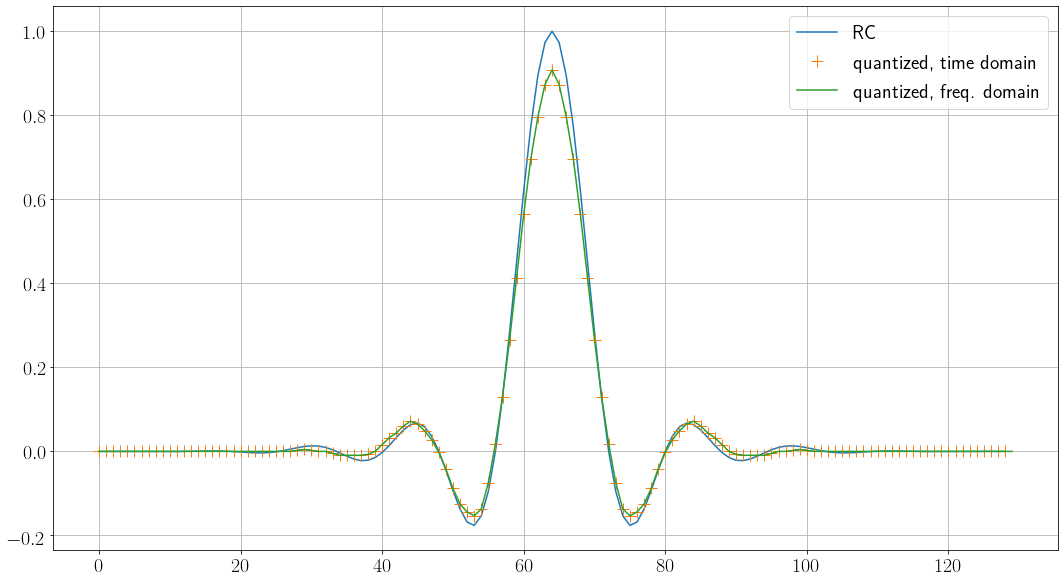

In [31]:
plt.plot( rc_ideal, label='RC')

plt.plot( rc_quant_time, '+', ms=12, label='quantized, time domain')
plt.plot( rc_quant_freq, label='quantized, freq. domain')
plt.grid(True)
plt.legend(loc='upper right')